<a href="https://colab.research.google.com/github/liuxiaohu0511/lance-demo/blob/develop/lance_distribute_write.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pylance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 19.6 MB/s eta 0:00:00


In [3]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa
import duckdb

lance格式支持多个分布式工作者并行写入。分布式写操作可以通过两阶段完成：
1. 并行写入：并行跨多个worker生成lance.LanceFragment。
2. 提交：收集所有的lance.LanceFragment并在单个lance.LanceOperation中提交到单个数据集中。

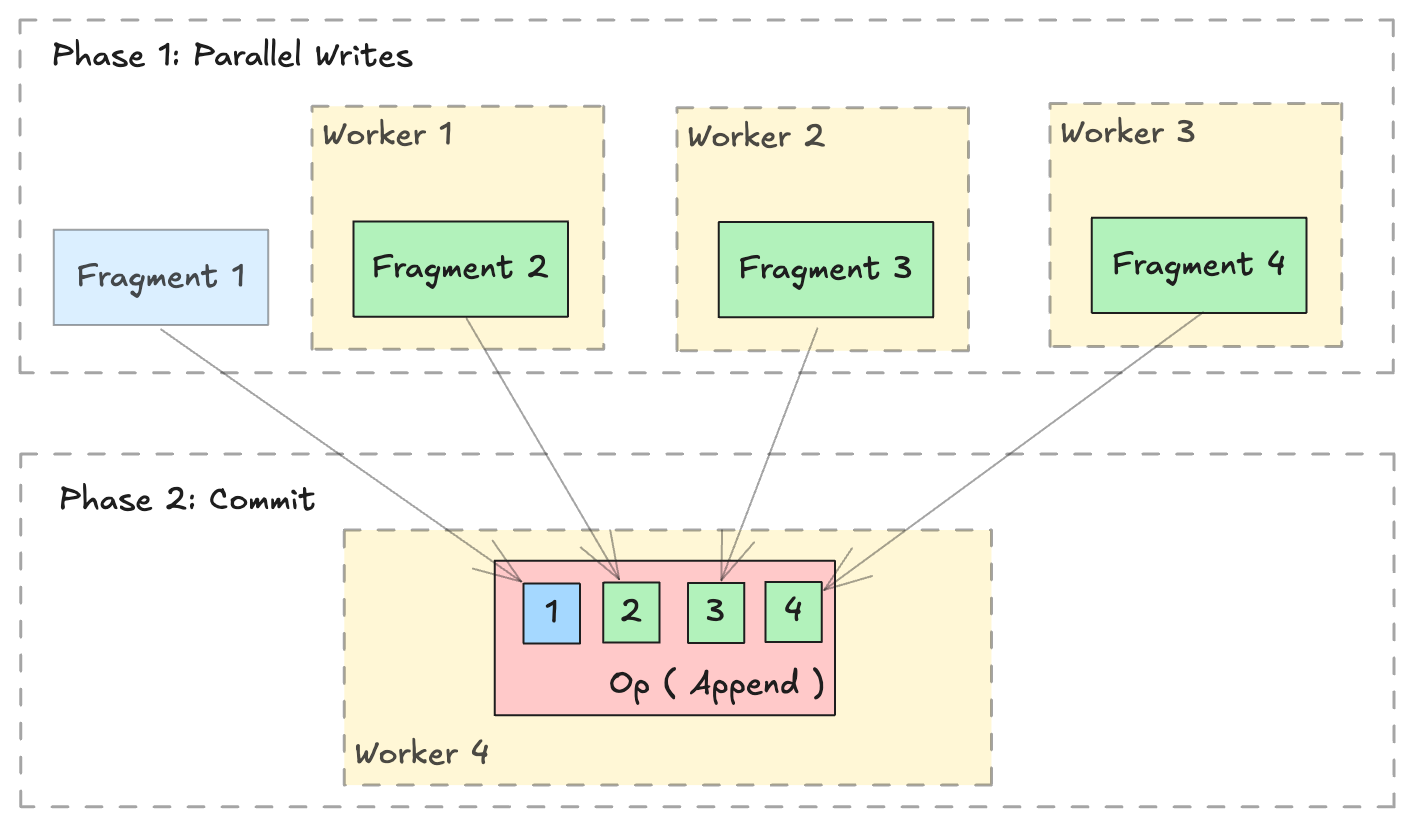

写入新数据，使用 lance.fragment.write_fragments 写入或追加新数据非常简单。

In [4]:
import json
from lance.fragment import write_fragments

# Run on each worker
data_uri = "./dist_write"
schema = pa.schema([
    ("a", pa.int32()),
    ("b", pa.string()),
])

# Run on worker 1
data1 = {
    "a": [1, 2, 3],
    "b": ["x", "y", "z"],
}
fragments_1 = write_fragments(data1, data_uri, schema=schema)
print("Worker 1: ", fragments_1)

# Run on worker 2
data2 = {
    "a": [4, 5, 6],
    "b": ["u", "v", "w"],
}
fragments_2 = write_fragments(data2, data_uri, schema=schema)
print("Worker 2: ", fragments_2)

Worker 1:  [FragmentMetadata(id=0, files=[DataFile(path='01101010100001110010110125482243f2b992dfceca6e3484.lance', fields=[0, 1], column_indices=[0, 1], file_major_version=2, file_minor_version=0, file_size_bytes=588)], physical_rows=3, deletion_file=None, row_id_meta=None)]
Worker 2:  [FragmentMetadata(id=0, files=[DataFile(path='000110001011100111101010ad9dd64e8b8bb121bde5e3a2aa.lance', fields=[0, 1], column_indices=[0, 1], file_major_version=2, file_minor_version=0, file_size_bytes=588)], physical_rows=3, deletion_file=None, row_id_meta=None)]


现在，使用 lance.fragment.FragmentMetadata.to_json 序列化片段元数据，并在单个工作程序上收集所有序列化元数据以执行最终提交操作。

In [5]:
import json
from lance import FragmentMetadata, LanceOperation

# Serialize Fragments into JSON data
fragments_json1 = [json.dumps(fragment.to_json()) for fragment in fragments_1]
print(f"fragments_json1: {fragments_json1}")
fragments_json2 = [json.dumps(fragment.to_json()) for fragment in fragments_2]
print(f"fragments_json2: {fragments_json2}")
# On one worker, collect all fragments
all_fragments = [FragmentMetadata.from_json(f) for f in \
    fragments_json1 + fragments_json2]

# Commit the fragments into a single dataset
# Use LanceOperation.Overwrite to overwrite the dataset or create new dataset.
op = lance.LanceOperation.Overwrite(schema, all_fragments)
read_version = 0 # Because it is empty at the time.
lance.LanceDataset.commit(
    data_uri,
    op,
    read_version=read_version,
)

# We can read the dataset using the Lance API:
dataset = lance.dataset(data_uri)
assert len(dataset.get_fragments()) == 2
assert dataset.version == 1
print(dataset.to_table().to_pandas())

fragments_json1: ['{"id": 0, "files": [{"fields": [0, 1], "column_indices": [0, 1], "file_major_version": 2, "file_minor_version": 0, "file_size_bytes": 588, "base_id": null, "path": "01101010100001110010110125482243f2b992dfceca6e3484.lance"}], "physical_rows": 3, "deletion_file": null, "row_id_meta": null}']
fragments_json2: ['{"id": 0, "files": [{"fields": [0, 1], "column_indices": [0, 1], "file_major_version": 2, "file_minor_version": 0, "file_size_bytes": 588, "base_id": null, "path": "000110001011100111101010ad9dd64e8b8bb121bde5e3a2aa.lance"}], "physical_rows": 3, "deletion_file": null, "row_id_meta": null}']
   a  b
0  1  x
1  2  y
2  3  z
3  4  u
4  5  v
5  6  w


**追加数据**

追加额外数据遵循类似的过程。使用 lance.LanceOperation.Append 提交新片段，确保 read_version 设置为当前数据集的版本。

In [10]:
import lance

ds = lance.dataset(data_uri)
read_version = ds.version # record the read version
print(read_version)
op = lance.LanceOperation.Append(all_fragments)
lance.LanceDataset.commit(
    data_uri,
    op,
    read_version=read_version,
)

ds.to_table().to_pandas()

2


,a,b
0,1,x
1,2,y
2,3,z
3,4,u
4,5,v
5,6,w
6,1,x
7,2,y
8,3,z
9,4,u


**添加新列**

Lance 格式在添加列等操作上表现出色。得益于其二维布局（参见这篇博客文章），添加新列非常高效，因为它避免了复制现有数据文件。相反，这个过程只需创建新的数据文件，并通过仅使用元数据操作将它们链接到现有数据集。


In [15]:
import lance
from pyarrow import RecordBatch
import pyarrow.compute as pc


if False:
  # 初始化数据
  # 1. 定义数据schema（字段结构）
  schema = pa.schema([
      pa.field("name", pa.string()),  # 姓名（字符串类型）
      pa.field("age", pa.int64())     # 年龄（整数类型）
  ])


  # 2. 创建初始数据集（含2个分片，用于后续并行处理）
  # 初始数据分两批写入，生成2个分片
  data_batch1 = pa.Table.from_pydict(
      {"name": ["alice", "bob", "charlie"], "age": [25, 33, 44]},
      schema=schema
  )
  data_batch2 = pa.Table.from_pydict(
      {"name": ["craig", "dave", "eve"], "age": [55, 66, 77]},
      schema=schema
  )

  # 写入数据集（首次创建用mode="create"，追加用mode="append"）
  lance.write_dataset(data_batch1, "./add_columns_example", mode="overwrite")
  lance.write_dataset(data_batch2, "./add_columns_example", mode="append")

if False:
  dataset = lance.dataset("./add_columns_example")
  assert len(dataset.get_fragments()) == 2
  assert dataset.to_table().combine_chunks() == pa.Table.from_pydict({
      "name": ["alice", "bob", "charlie", "craig", "dave", "eve"],
      "age": [25, 33, 44, 55, 66, 77],
  }, schema=schema)


  def name_len(names: RecordBatch) -> RecordBatch:
      return RecordBatch.from_arrays(
          [pc.utf8_length(names["name"])],
          ["name_len"],
      )

  # On Worker 1
  frag1 = dataset.get_fragments()[0]
  new_fragment1, new_schema = frag1.merge_columns(name_len, ["name"])

  # On Worker 2
  frag2 = dataset.get_fragments()[1]
  new_fragment2, _ = frag2.merge_columns(name_len, ["name"])

  # On Worker 3 - Commit
  all_fragments = [new_fragment1, new_fragment2]
  op = lance.LanceOperation.Merge(all_fragments, schema=new_schema)
  lance.LanceDataset.commit(
      "./add_columns_example",
      op,
      read_version=dataset.version,
  )

  # Verify dataset
  dataset = lance.dataset("./add_columns_example")
  print(dataset.to_table().to_pandas())

      name  age  name_len
0    alice   25         5
1      bob   33         3
2  charlie   44         7
3    craig   55         5
4     dave   66         4
5      eve   77         3


In [24]:
dataset = lance.dataset("./add_columns_example", version=5)
dataset.to_table().to_pandas()

,name,age,name_len
0,alice,25,5
1,bob,33,3
2,charlie,44,7
3,craig,55,5
4,dave,66,4
5,eve,77,3
